In [4]:
import pandas as pd

# Data load karna (encoding zaroori hai is file ke liye)
df = pd.read_csv("sales.csv.csv", encoding="latin1")

# Pehle 5 rows screen par dekhna
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
# Check total rows, columns aur data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
# Kis column me kitne missing values hain
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [7]:
# Date format convert karne
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")

# Month ka naya column create karna
df["Month"] = df["Order Date"].dt.month_name()

# Check karein naya column aaya ya nahi
df[["Order Date", "Month", "Sales"]].head()

,Order Date,Month,Sales
0,2017-11-08,November,261.9600
1,2017-11-08,November,731.9400
2,2017-06-12,June,14.6200
3,2016-10-11,October,957.5775
4,2016-10-11,October,22.3680


In [8]:
# Category wise total sales calculate karna
category_sales =(
    df.groupby("Category")["Sales"]
    .sum()
    .reset_index()
    .sort_values(by="Sales", ascending=False)
)
category_sales

,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


C:\Users\ashok\AppData\Local\Temp\ipykernel_16536\1695203725.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Sales", data=category_sales, palette="Blues_r")


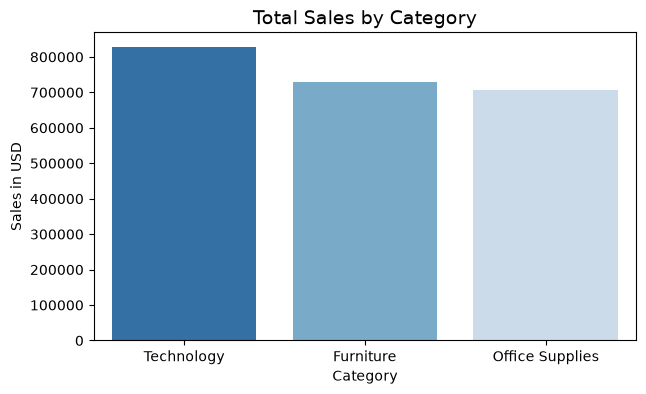

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 4))
sns.barplot(x="Category", y="Sales", data=category_sales, palette="Blues_r")
plt.title("Total Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Sales in USD")
plt.show()

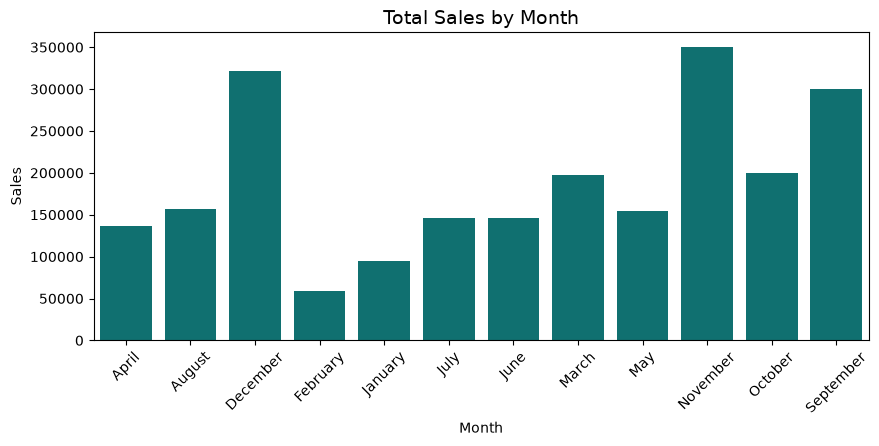

In [12]:
# Month wise sales
monthly_sales = df.groupby("Month")["Sales"].sum().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(x="Month", y="Sales", data=monthly_sales, color="teal")
plt.title("Total Sales by Month", fontsize=14)
plt.xticks(rotation=45)
plt.show()

C:\Users\ashok\AppData\Local\Temp\ipykernel_16536\3353820074.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Sales", y="City", data=top_cities, palette="viridis")


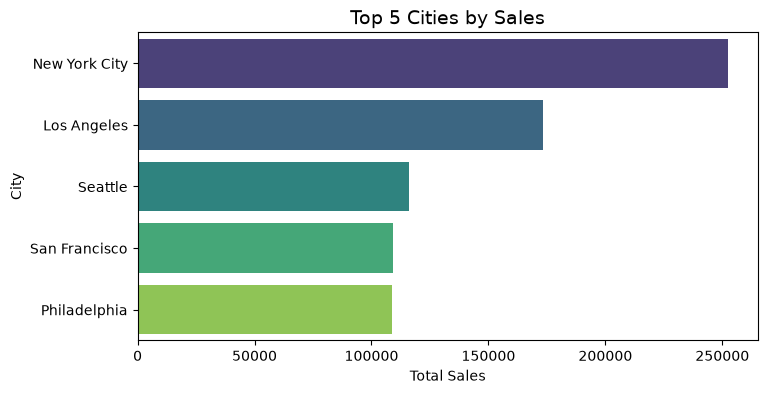

In [13]:
# Top 5 cities nikalna
top_cities = (
    df.groupby("City")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False).head(5)
)

# Top 5 Cities ka Horizontal Bar Chart
plt.figure(figsize=(8, 4))
sns.barplot(x="Sales", y="City", data=top_cities, palette="viridis")
plt.title("Top 5 Cities by Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()

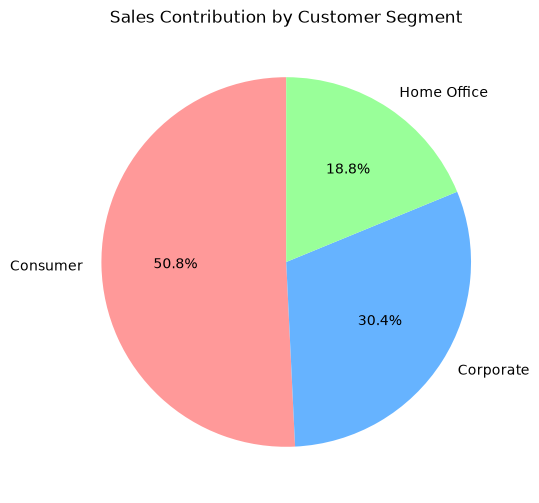

In [15]:
# Segment wise sales ka share
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(6, 6))
segment_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff9999", "#66b3ff", "#99ff99"],
)
plt.title("Sales Contribution by Customer Segment")
plt.ylabel("") # clean look ke liye empty label
plt.show()